# 1. Import Packages

In [ ]:
!pip install Sastrawi

In [ ]:
import numpy as np
import pandas as pd
from string import punctuation
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

In [ ]:
sw_punct = StopWordRemoverFactory().get_stop_words() + list(punctuation)

# 2. Load Data

In [ ]:
df = pd.read_csv('/content/spam.csv')
df

,Teks,label
0,[PROMO] Beli paket Flash mulai 1GB di MY TELKO...,1
1,2.5 GB/30 hari hanya Rp 35 Ribu Spesial buat A...,1
2,"2016-07-08 11:47:11.Plg Yth, sisa kuota Flash ...",1
3,"2016-08-07 11:29:47.Plg Yth, sisa kuota Flash ...",1
4,4.5GB/30 hari hanya Rp 55 Ribu Spesial buat an...,1
...,...,...
1138,"Yooo sama2, oke nanti aku umumin di grup kelas",0
1139,😁 sebelumnya ga ad nulis kerudung. Kirain warn...,0
1140,Mba mau kirim 300 ya,0
1141,nama1 beaok bwrangkat pagi...mau cas atay tra...,0


# 3. Mini EDA

## 3.1. Label Distribution

<Axes: xlabel='label'>

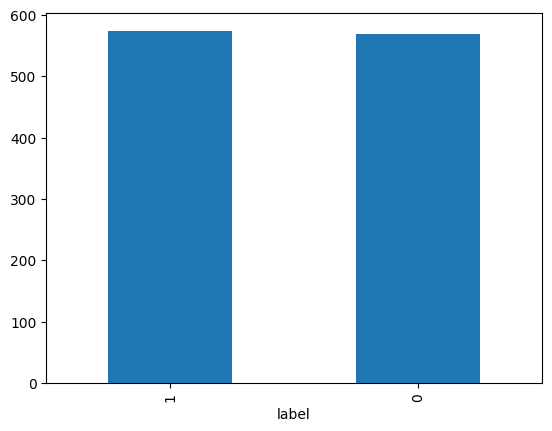

In [ ]:
df['label'].value_counts().plot(kind='bar')

## 3.2. WordCloud

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize

import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

### Spam

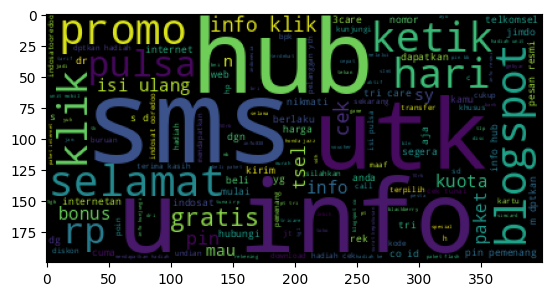

In [ ]:
## semua teks dijadikan 1 paragraf
all_teks = " ".join(df[df.label==1].Teks.values)  #jadikan 1 paragraf
all_teks = word_tokenize(all_teks.lower())        #jadikan huruf kecil, lalu ditokenisasi
all_teks = [item for item in all_teks if item not in sw_punct] #remove stopwords
all_teks = " ".join(all_teks)                     #disatukan ulang

wordclound = WordCloud().generate(all_teks)
plt.imshow(wordclound);

### Non Spam

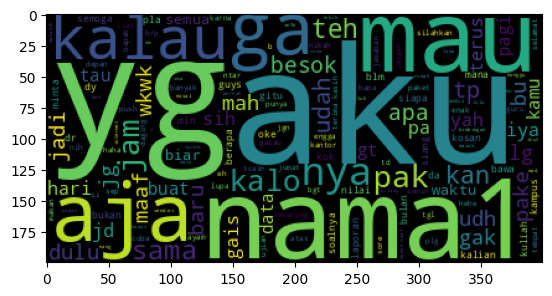

In [ ]:
## semua teks dijadikan 1 paragraf
all_teks = " ".join(df[df.label==0].Teks.values)  #jadikan 1 paragraf
all_teks = word_tokenize(all_teks.lower())        #jadikan huruf kecil, lalu ditokenisasi
all_teks = [item for item in all_teks if item not in sw_punct] #remove stopwords
all_teks = " ".join(all_teks)                     #disatukan ulang

wordclound = WordCloud().generate(all_teks)
plt.imshow(wordclound);

# 4. Data Preprocessing

In [ ]:
## data yang akan diubah menjadi vektor
X = df['Teks']

## label
y = df['label']

## Word Embedding by TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
embedding_model  = TfidfVectorizer(stop_words=sw_punct,ngram_range=(1,1))
embedding_matrix = embedding_model.fit_transform(X)

X_embedding = pd.DataFrame(embedding_matrix.toarray())

In [ ]:
X_embedding.shape

(1143, 4857)

# 5. Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_embedding,y,test_size=0.2,
                                                    random_state=1,stratify=y)

# 6. Modeling

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

parameter = {
    'C' : [10,1,0.1, 0.001, 0.001],
    'fit_intercept':[True,False]
}

In [ ]:
model = GridSearchCV(LogisticRegression(),parameter,verbose=1)
model.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(estimator=LogisticRegression(),
             param_grid={'C': [10, 1, 0.1, 0.001, 0.001],
                         'fit_intercept': [True, False]},
             verbose=1)

In [ ]:
from sklearn.metrics import classification_report

def classification_score(model,X,y):
    y_predicted = model.predict(X)
    print(classification_report(y,y_predicted))

classification_score(model,X_test,y_test)

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       114
           1       0.98      0.97      0.97       115

    accuracy                           0.97       229
   macro avg       0.97      0.97      0.97       229
weighted avg       0.97      0.97      0.97       229



# 7. Backtest

In [ ]:
text_1 = ["Sayng belikan aku pulsa di nmr ini 085212345678 nanti aq tlpn qmu balik, aq pke hp tmn"]
text_2 = ["Besok kita masuk kuliah jam 07:30 di gedung A."]
text_3 = ["""TUTUP CC & KTA ANDA, KAMI BANTU DNGN 2 SOLUSI:
             1. CICIL TETAP BUNGA 2%
             2. DISC PELUNASAN 30% S/D 60%
             CLEAR BI & LEGAL
             INFO :
             TELP/WA : SARI 085212345678"""]

In [ ]:
def predict_spam(model,text):
    ## word embedding
    text_embedding = embedding_model.transform(text).toarray()

    ## prediction
    prediction = model.predict(text_embedding)[0]

    ## prediction classification
    if prediction == 1:
      return 'Spam'
    else :
      return 'Non Spam'

In [ ]:
predict_spam(model,text_3)

'Spam'